#Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


##Task 1: Data Preparation

##Loading the Data

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI-ML/Week-4/devnagari digit.zip'
data_path = '/content/drive/MyDrive/AI-ML/Week-4/data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")


Successfully unzipped '/content/drive/MyDrive/AI-ML/Week-4/devnagari digit.zip' to '/content/drive/MyDrive/AI-ML/Week-4'


Train shape: (17000, 28, 28, 1)
Test shape: (3000, 28, 28, 1)


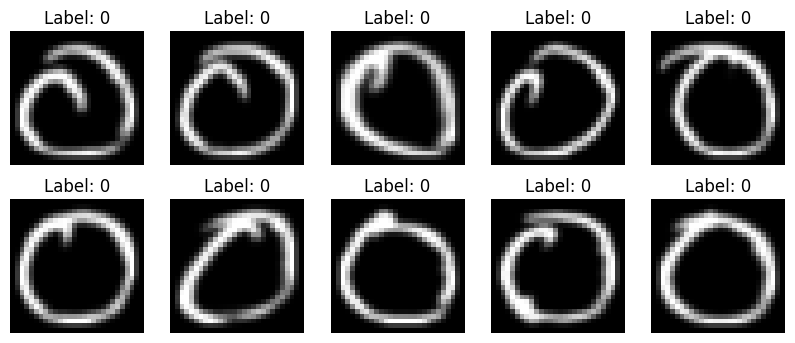

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# Dataset paths
train_dir = "/content/drive/MyDrive/AI-ML/Week-4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI-ML/Week-4/DevanagariHandwrittenDigitDataset/Test"

# Image size
img_height, img_width = 28, 28

# Function to load images
def load_images(folder):
    images = []
    labels = []

    # Get class folders (0–9)
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    # Loop through each class
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            # Convert to grayscale
            img = Image.open(img_path).convert("L")

            # Resize image to 28x28
            img = img.resize((28, 28))

            # Normalize pixel values (0–255 → 0–1)
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load dataset
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# Reshape for neural network (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

##Task 2: Build FCN Model

##Model Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Fully Connected Network (FCN)
model = Sequential([
    # Convert 2D image → 1D vector
    Flatten(input_shape=(28, 28, 1)),

    # Hidden layers
    Dense(64, activation='sigmoid'),   # First hidden layer
    Dense(128, activation='sigmoid'),  # Second hidden layer
    Dense(256, activation='sigmoid'),  # Third hidden layer

    # Output layer (10 classes)
    Dense(10, activation='softmax')
])

# Show model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
# Input layer
  inputs = keras.Input(shape=input_shape)
  # Flatten layer
  x = keras.layers.Flatten()(inputs)
  # Hidden layers
  x = keras.layers.Dense(64, activation="sigmoid")(x)
  x = keras.layers.Dense(128, activation="sigmoid")(x)
  x = keras.layers.Dense(256, activation="sigmoid")(x)
  # Output layer
  outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
  # Create model
  model = keras.Model(inputs=inputs, outputs=outputs)
  return model
# Build the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 3: Compile the Model

##Model Compilation

In [ ]:
model.compile(
    optimizer='adam',                 # Better than SGD (adaptive learning)
    loss='categorical_crossentropy',  # For multi-class classification
    metrics=['accuracy']              # Evaluate performance
)

##Task 4: Train the Model

##Model Training

In [ ]:
from tensorflow import keras

batch_size = 128
epochs = 20

# Callbacks improve training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",  # Save best model
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",           # Stop if validation loss not improving
        patience=4
    )
]

# Train model
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4471 - loss: 1.6881 - val_accuracy: 0.0000e+00 - val_loss: 6.9637
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8187 - loss: 0.5485 - val_accuracy: 0.0000e+00 - val_loss: 8.2399
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8999 - loss: 0.3042 - val_accuracy: 0.0000e+00 - val_loss: 8.7175
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9423 - loss: 0.2031 - val_accuracy: 0.0000e+00 - val_loss: 9.0933
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9538 - loss: 0.1561 - val_accuracy: 0.0000e+00 - val_loss: 9.4973


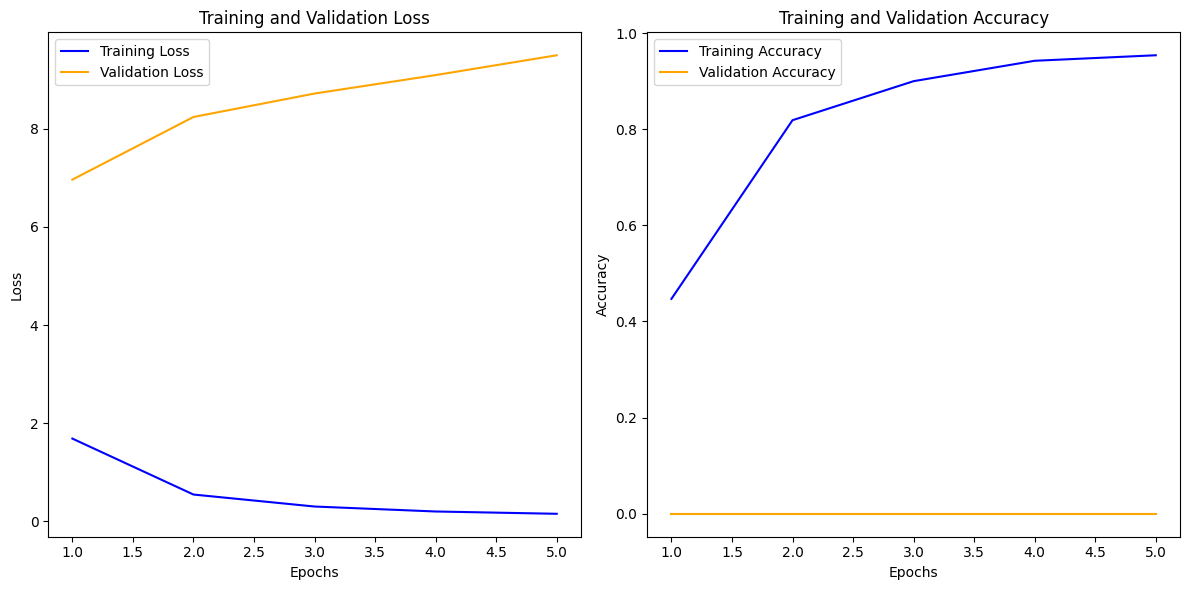

In [ ]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

##Task 5: Evaluate the Model

##Model Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7613 - loss: 2.0257
Test Accuracy: 0.7613333463668823
Test Loss: 2.0256874561309814


##Task 6: Save and Load the Model

##Model Saving and Loading

In [ ]:
model.save("fcn_devnagari_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("fcn_devnagari_model.h5")

loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7613 - loss: 2.0257
Loaded Model Accuracy: 0.7613333463668823


##Task 7: Predictions

##Making Predictions

In [ ]:
predictions = model.predict(x_test)

# Convert probabilities → class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 0 0 0 0 0 0]
